---------

## Feature transformation: Weight of Evidence

The purpose of this notebook is to explore the Weight of Evidence (WoE) transformation for features used in a binary classification model. The transformation process is as follows:

- Bin your variable up into groups, where each group should have roughly the same relationship with the target
- Calculate the WoE for each group (calculation below)
- Replace the feature value with the WoE value corresponding to the group that it belongs to. For example, if your feature is equal to 50 and one of your bins is for values in the range 0-100, then replace the WoE for the 0-100 group would replace the 50. Similarly, if your feature is 60 then it would get the same value

### WoE definition

For a given bin, $i$, the weight of evidence can be calculated as:

$ WoE_{i} = log(\frac{(N_{i} - E_{i})/(N_{T} - E_{T})}{E_{i}/E_{T}}) $

where $E$ and $N$ represent the total number of events and the total number of samples, respectively. In this form the numerator is referred to as the % of non-events and the denominator is referred to as the % of events, i.e. the log of the % of non-events over the % of events. This is the typical way that the WoE is represented but I don't have a great intuition for what it means. I have found it easier to interpret when the equation is rewritten in this form,

$ WoE_{i} = log(\frac{E_{T}}{N_{T} - E_{T}}) - log(\frac{E_{i}}{N_{i} - E_{i}}) (*)$   

Now we can see the WoE for a bin is equal to the log odds of the overall sample minus the log odds of the bin itself. In this way you can see that by having a more extreme spread of WoE values across your bins indicates that your variable is offering more information about the target, assuming there are the same number of samples in each bin.

Another reason for preferring the second equation is that it more intuitively explains the reason why WoE transforming is effective in the context of fitting a logistic regression model since the WoE for a bin is directly related to its log odds and a logistic regression model assumes a linear relationship between the features and the log odds - in this sense it is a sort of target encoding tranformation (something to be discussed later!!!!!). By WoE-transforming a variable we are ensuring that there is a perfectly linear relationship between the input feature (the transformed variable) and the log odds **for each bin**. Note that this does not mean that there is now a perfectly linear relationship between the feature and the target since we have binned the variable. and in this way we may be losing information which differentiates samples within a bin because we assume that they all behave identically.

### Why is WoE used?

In simple terms, WoE-transforming is a very effective and easy way of transforming variables for a logistic regression model without the need to explore complicated transformations, particularly when there is a non-linear relationship between the feature and the log odds. 

By binning variables we are also imposing a kind of regularisation which will assist with preventing overfitting. In a sense there are two processes going on here:
- Binning: this helps with regularisation
- Converting to WoE values: this maps our bins into the log-odds space (the exact space that logistic regression operates in)

Finally, it allows practitioners to produce highly interpretable and stable models without requiring more complex modelling techniques. Although modern machine learning approaches may achieve superior predictive performance, WoE-based scorecards remain popular in credit risk because they are very transparent - a characteristic that is very important in a highly regulated environment such as credit risk.

## An example

Below we create some dummy data. We define a feature which contains random numbers sampled from a uniform distribution. We then define a binary target where the probability of the +ve class is

$ P(1 | X) = \frac{1}{1 + exp(-(X + \sigma))} $

where $X$ is the feature value and $\sigma$ represents some random noise. Note that this means that the $log(odds)$ is equal to $X + \sigma$. We choose the feature range such that the target is skewed towards the -ve class.

In [1]:
%load_ext autoreload
%autoreload 2

In [112]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.datasets import make_classification
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split

import sys
sys.path.append("../")
from utils.eda import feature_summary, plot_feature

Mean target:  0.1573


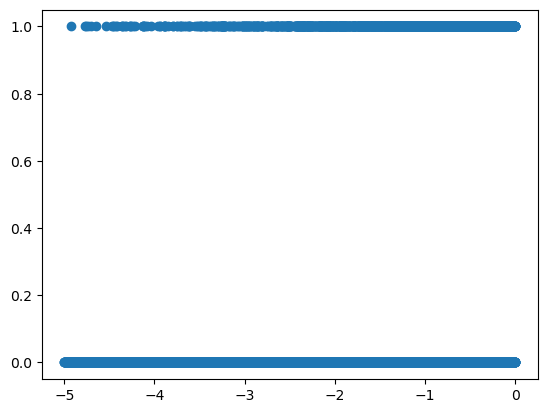

In [92]:
n_rows = 10_000
target = "target"

np.random.seed(n_rows)  # Set seed for reproducibility

df = pd.DataFrame({"feature_0": np.random.uniform(-5, 0, size=n_rows)})

probs = 1 / (1 + np.exp(-(df["feature_0"] + np.random.normal(size=n_rows))))
df["target"] = np.random.binomial(1, p=probs, size=n_rows)
target_mean = df[target].mean()

print("Mean target: ", target_mean)

fig, ax = plt.subplots()
ax.scatter(df["feature_0"], df[target]);

-------

## EDA

At this point we will split the data into a train and test set. We will use the train set for all analysis, transformations, and model building and then return to the test set later.

We now summarise the target by our feature such that we have 10 bins of approximately equal size and we calculate the mean target, log odds, and WoE within each bin. Note that we define our bin edges based on the train set, but we include the min and max values of the entire dataset. This is so that when we bin the test set later then there are no values excluded.

Notice in the left plot in the second set of charts that the WoE and log odds are mirror images of each other. This no coincidence and is a consequence of the starred equation at the top of this notebook, which says that the WoE for the bin $i$ is equal to,

$ WoE_{i} = log(odds) - log(odds_{i}) $

where $log(odds)$ is equal to the log odds of the overall sample.

To really hammer this point home, there is a second plot which plots the log odds against the WoE, illustrating this perfectly linear relationship.

In [93]:
train, test = train_test_split(df, test_size=0.3, random_state=666)
train.shape, test.shape, train["feature_0"].min(), test["feature_0"].min()

((7000, 2), (3000, 2), -4.998721686278712, -4.997345200810612)

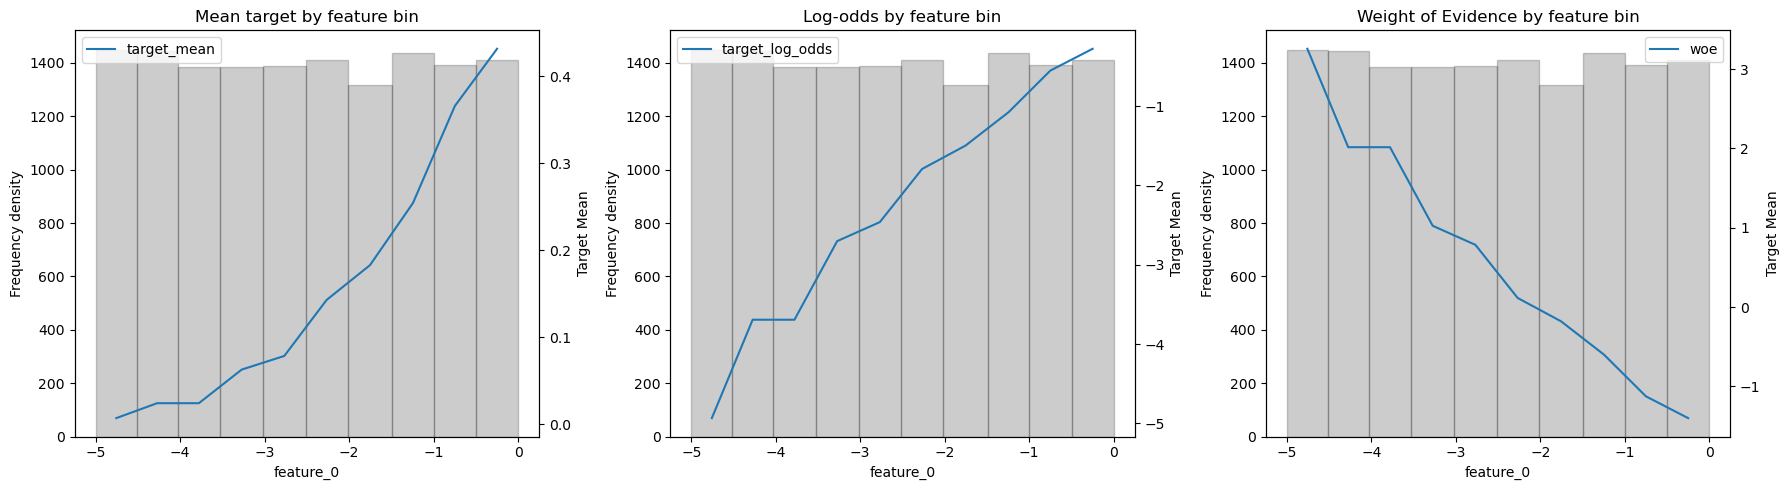

In [94]:
feature = "feature_0"

_, bin_edges = pd.qcut(train[feature], q=10, retbins=True, duplicates="drop")
bin_edges[0], bin_edges[-1] = df[feature].min(), df[feature].max()

train_summary = feature_summary(train, feature, target, bins=bin_edges, for_plotting=True)

# --- add log odds and WoE to summary ---
train_summary[f"{target}_log_odds"] = np.log(train_summary[f"{target}_mean"] / (1 - train_summary[f"{target}_mean"]))
overall_log_odds = np.log(train[target].mean() / (1 - train[target].mean()))
train_summary["woe"] = overall_log_odds - np.log(train_summary[f"{target}_mean"] / (1 - train_summary[f"{target}_mean"]))

# --- plotting ---
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(18, 5))
fig = plot_feature(train_summary, feature, ["target_mean"], ax=ax1)
fig = plot_feature(train_summary, feature, ["target_log_odds"], ax=ax2)
fig = plot_feature(train_summary, feature, ["woe"], ax=ax3)

ax1.set_title("Mean target by feature bin")
ax2.set_title("Log-odds by feature bin")
ax3.set_title("Weight of Evidence by feature bin")

fig.tight_layout()
fig

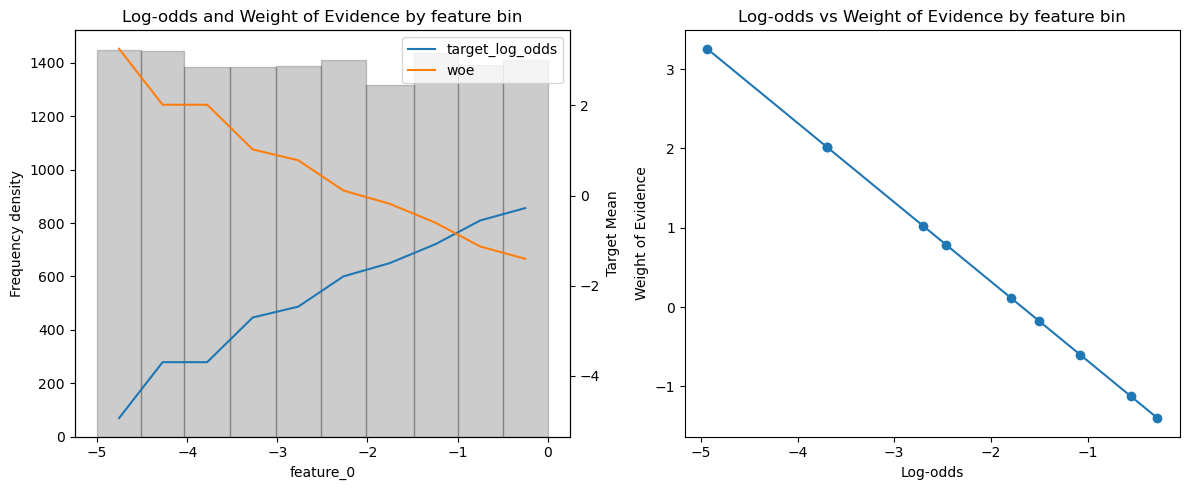

In [95]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

fig = plot_feature(train_summary, feature, ["target_log_odds", "woe"], ax=ax1)
ax1.set_title("Log-odds and Weight of Evidence by feature bin")

ax2.plot(
    train_summary.loc[np.argsort(train_summary["target_log_odds"]), ["target_log_odds"]],
    train_summary.loc[np.argsort(train_summary["target_log_odds"]), ["woe"]],
    marker="o",
)
ax2.set_title("Log-odds vs Weight of Evidence by feature bin")
ax2.set_xlabel("Log-odds")
ax2.set_ylabel("Weight of Evidence")

fig.tight_layout()
fig

-------

## Feature transformation

Now we perform the WoE transformation. We bin up our feature column and add the WoE value that corresponds to each bin as a new column. Below you can see the summary table which contains one row per bin and the WoE value for that bin. By comparing this against the second table, which shows the dataframe with the new transformed column, you can see where the WoE value has come from and how each sample has been classified to a particular bin.

In the next charts we show the transformed feature for each bin. The left-hand chart is simply a replica of that shown above, however the second charts shows our transformed feature when we use 20 bins rather than 10. We can now see that adjacent bins have identical transformed values. Essentially we have just split each of the 10 bins into two and since every sample within a bin gets the same WoE value, it holds that the average of the two individual bins would be identical. 

This chart shows one weakness of the WoE-transformation, and in particular the binning effect, which results in step changes over a continuous variable. The benefit of binning is that it enforces a kind of regularisation, but the disadvantage is that we may lose out on information within the bins. It is also worth considering whether step changes are desirable for implementation. There are some use cases where step changes in predictions might seem strange to an end user.

In [96]:
train_summary[["feature_0_10b", "woe"]]

,feature_0_10b,woe
0,"(-5.0, -4.516]",3.256987
1,"(-4.516, -4.032]",2.015795
2,"(-4.032, -3.526]",2.015795
3,"(-3.526, -3.02]",1.024485
4,"(-3.02, -2.516]",0.784431
5,"(-2.516, -2.02]",0.114273
6,"(-2.02, -1.488]",-0.180378
7,"(-1.488, -1.001]",-0.601603
8,"(-1.001, -0.497]",-1.126839
9,"(-0.497, -0.000806]",-1.401462


In [97]:
# Add WOE values back to the train dataframe
train["feature_0_10b"] = pd.cut(train[feature], bins=bin_edges, duplicates="drop", include_lowest=True)
train = train.merge(
    train_summary[["feature_0_10b", "woe"]],
    on=["feature_0_10b"],
)
train.head()

,feature_0,target,feature_0_10b,woe
0,-2.194661,0,"(-2.516, -2.02]",0.114273
1,-3.508334,0,"(-3.526, -3.02]",1.024485
2,-4.628457,0,"(-5.0, -4.516]",3.256987
3,-4.617730,0,"(-5.0, -4.516]",3.256987
4,-4.862722,0,"(-5.0, -4.516]",3.256987


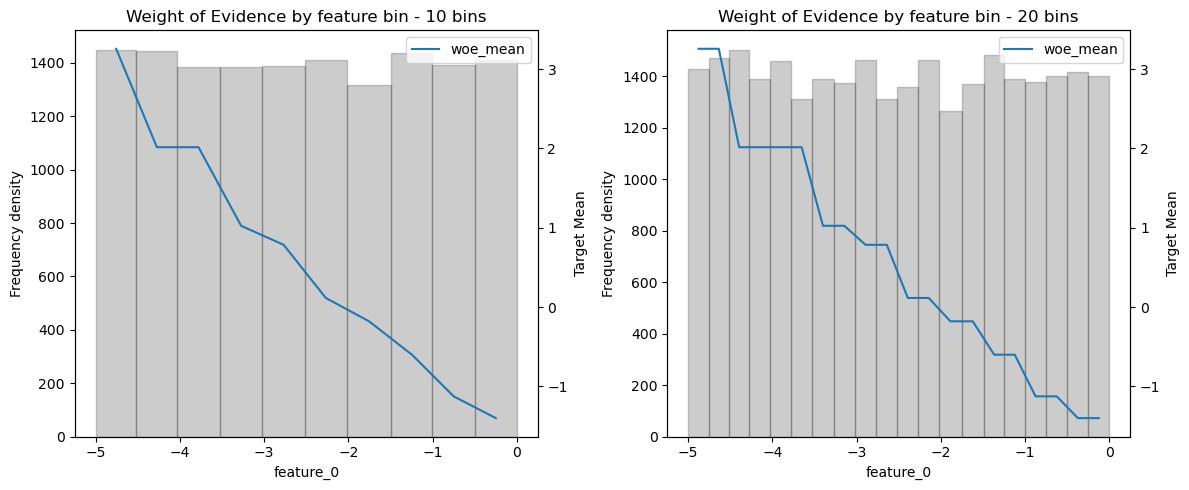

In [98]:
train_summary_10 = feature_summary(train, feature, "woe", bins=bin_edges, for_plotting=True)

# insert the bin midpoint as another break so we get 20 bins
bin_edges_20 = np.append(
    np.column_stack(
        [
            bin_edges[:-1],
            train_summary_10["bin_mid"],
        ]
    ).reshape(-1, 1),
    bin_edges[-1]
)
train_summary_20 = feature_summary(train, feature, "woe", bins=bin_edges_20, for_plotting=True)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

fig = plot_feature(train_summary_10, feature, ["woe_mean"], ax=ax1)
fig = plot_feature(train_summary_20, feature, ["woe_mean"], ax=ax2)

ax1.set_title("Weight of Evidence by feature bin - 10 bins")
ax2.set_title("Weight of Evidence by feature bin - 20 bins")

fig.tight_layout()
fig

---------

## Modelling

We now fit a logistic regression model to our transformed feature. Two significant things happen which both tie directly back to the WoE equations from earlier. Our model takes the form:

$log(odds) = \beta_0 + \beta_1 \cdot WoE$

Recall from our starred equation that for any bin $i$:

$WoE_i = log(odds_{overall}) - log(odds_i)$

Now, when we fit the model via maximum likelihood estimation, we observe two key properties:

1. **The constant equals the overall log odds**: $\beta_0 = log(odds_{overall})$
2. **The WoE coefficient equals -1**: $\beta_1 = -1$

This is not a coincidence - it follows directly from the WoE construction. Substituting these values back into our model for a sample in bin $i$, our predicted log odds are,

$\hat{\log}(odds_i) = log(odds_{overall}) + (-1) \cdot (log(odds_{overall}) - log(odds_i))$

$\hat{\log}(odds_i) = log(odds_{overall}) - log(odds_{overall}) + log(odds_i)$

$\hat{\log}(odds_i) = log(odds_i)$

In other words, the model perfectly recovers the observed log odds for each bin. this is why WoE-transforming can be so effective for logistic regression. By transforming features into the log-odds space, we create a perfectly linear relationship between the transformed feature and the target log odds, which is exactly what logistic regression assumes.

The charts below show the actuals against predictions. The left-hand chart is good illustration that we have perfectly replicated the actuals within each bin by fitting to the WoE, where the WoE transformation used exactly the same bins. Note that this does not mean that we have perfectly replicated the actual values **for every sample**. It is only when binning at the same level that the transformation was performed that we get identical predictions and actuals. The right-hand charts shows the average predictions when grouping into 20 bins. Now the step chanegs discussed above are visible and it is clear that there is as a difference between our actuals and predictions.

In [99]:
overall_log_odds = np.log(train[target].mean() / (1 - train[target].mean()))

model = sm.Logit(train[target], sm.add_constant(train["woe"])).fit()
print(model.summary())

print("\nOverall log-odds: ", overall_log_odds)

Optimization terminated successfully.
         Current function value: 0.357416
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                 7000
Model:                          Logit   Df Residuals:                     6998
Method:                           MLE   Df Model:                            1
Date:                Mon, 25 May 2026   Pseudo R-squ.:                  0.1791
Time:                        17:15:04   Log-Likelihood:                -2501.9
converged:                       True   LL-Null:                       -3047.7
Covariance Type:            nonrobust   LLR p-value:                2.303e-239
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6775      0.039    -42.650      0.000      -1.755      -1.600
woe           -1.0000      0.

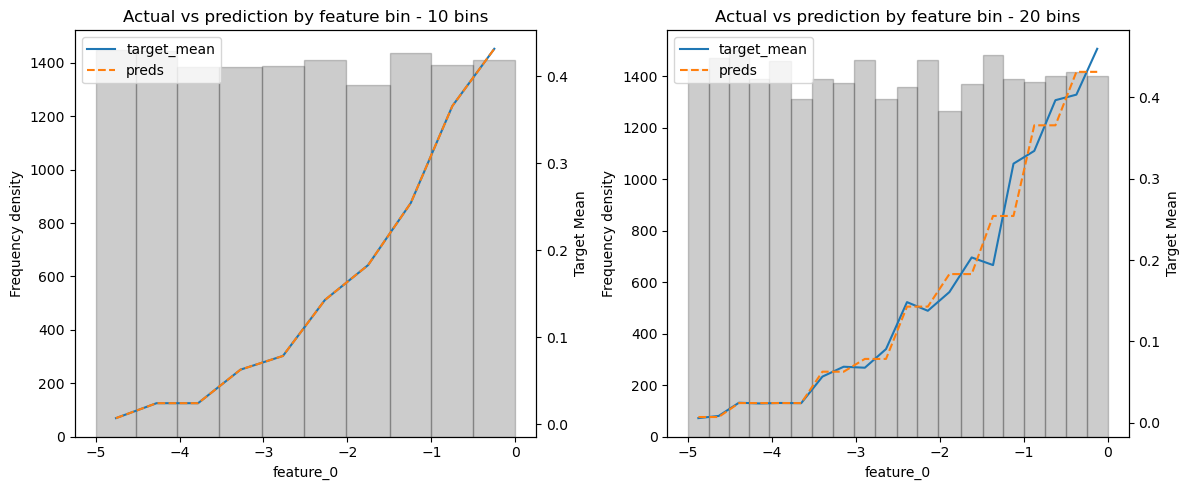

In [110]:
train["preds"] = model.predict(sm.add_constant(train["woe"]))

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

for axes, bins in zip((ax1, ax2), (bin_edges, bin_edges_20)):
    # summarise feature
    summary_preds = feature_summary(train, feature, "preds", bins=bins, for_plotting=True)
    summary_target = feature_summary(train, feature, target, bins=bins, for_plotting=False)

    summary_preds = summary_preds.merge(
        summary_target[[f"feature_0_{len(bins)-1}b", f"{target}_mean"]], on=f"feature_0_{len(bins)-1}b"
    )

    # plotting
    fig = plot_feature(summary_preds, feature, [f"{target}_mean"], ax=axes)

    axes_2 = axes.get_shared_x_axes().get_siblings(axes)[0]
    axes_2.plot(summary_preds["bin_mid"], summary_preds["preds_mean"], linestyle="--", label="preds")  # plot prediction mean
    axes_2.legend()

ax1.set_title("Actual vs prediction by feature bin - 10 bins")
ax2.set_title("Actual vs prediction by feature bin - 20 bins")

fig.tight_layout()
fig

-------

## Model performance

Now we reintroduce the test set. Notice that up to now we have only looked at the train set. This is really important for WoE transformations. It is clear from the above that we are essentially feeding the model information about the target directly by performing this transformation. If we were to perform a WoE transform including our test set then we would be feeding the model about our test set and then any performance metrics evaluated on the test set could not be trusted.

Below we make some predictions on the test set and show a comparison of the predictions vs actuals for each of the train and test set. Notice that the predicted values are equal for each dataset, and only the actuals deviate. We also show some performance metrics. Despite the WoE-transformation giving the model direct information about the target, there is no sign of overfitting. This is due to the binning process which negates overfitting to the train test.

The final chart takes the actual underlying relationship between the feature and the target, and compares it with the predicted probabilities. It is a clear demonstration of the step changes in the predictions. From this it may be clearer why the model will struggle to overfit too significantly when binning has been performed.

In [ ]:
# Add WOE values to the test dataframe and make predictions
test["feature_0_10b"] = pd.cut(test[feature], bins=bin_edges, include_lowest=True)

test = test.merge(
    train_summary[["feature_0_10b", "woe"]],
    on=["feature_0_10b"],
)
test["preds"] = model.predict(sm.add_constant(test["woe"]))

test.head()

,feature_0,target,feature_0_10b,woe,preds
0,-1.793253,0,"(-2.02, -1.488]",-0.180378,0.182857
1,-0.218336,1,"(-0.497, -0.000806]",-1.401462,0.431429
2,-4.366168,0,"(-4.516, -4.032]",2.015795,0.024286
3,-1.319608,0,"(-1.488, -1.001]",-0.601603,0.254286
4,-4.378742,0,"(-4.516, -4.032]",2.015795,0.024286


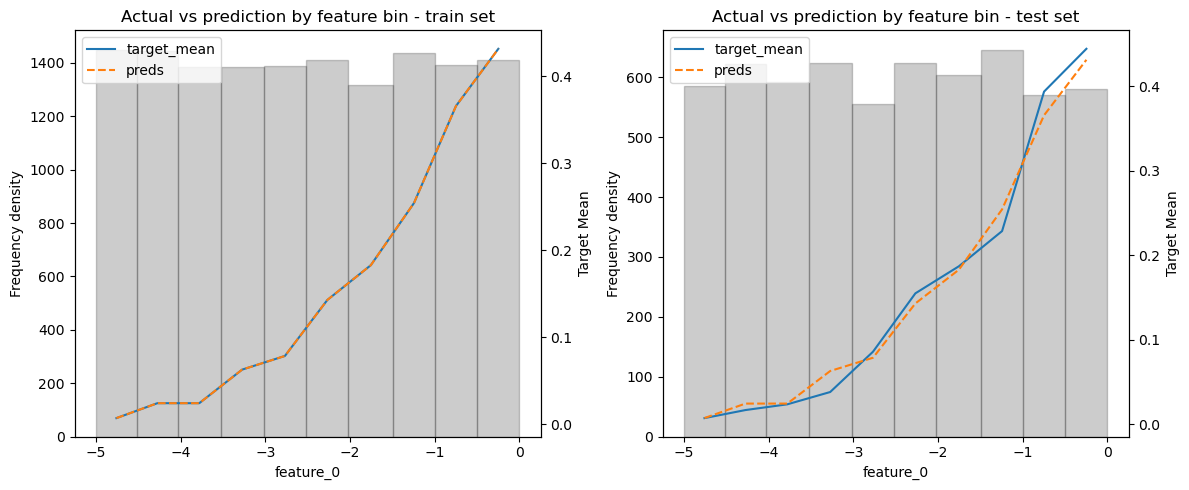

In [111]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

for axes, data in zip((ax1, ax2), (train, test)):
    # summarise feature
    summary_preds = feature_summary(data, feature, "preds", bins=bin_edges, for_plotting=True)
    summary_target = feature_summary(data, feature, target, bins=bin_edges, for_plotting=False)

    summary_preds = summary_preds.merge(
        summary_target[[f"feature_0_{len(bin_edges)-1}b", f"{target}_mean"]], on=f"feature_0_{len(bin_edges)-1}b"
    )

    # plotting
    fig = plot_feature(summary_preds, feature, [f"{target}_mean"], ax=axes)

    axes_2 = axes.get_shared_x_axes().get_siblings(axes)[0]
    axes_2.plot(summary_preds["bin_mid"], summary_preds["preds_mean"], linestyle="--", label="preds")  # plot prediction mean
    axes_2.legend()

ax1.set_title("Actual vs prediction by feature bin - train set")
ax2.set_title("Actual vs prediction by feature bin - test set")

fig.tight_layout()
fig

In [113]:
# ---- get some performance metrics
pd.DataFrame(
    [
        [roc_auc_score(train[target], train["preds"]), average_precision_score(train[target], train["preds"])],
        [roc_auc_score(test[target], test["preds"]), average_precision_score(test[target], test["preds"])],
    ], index=["Train", "Test"], columns=["AU-ROC curve", "AU-PR curve"]
)

,AU-ROC curve,AU-PR curve
Train,0.793372,0.355125
Test,0.802124,0.365700


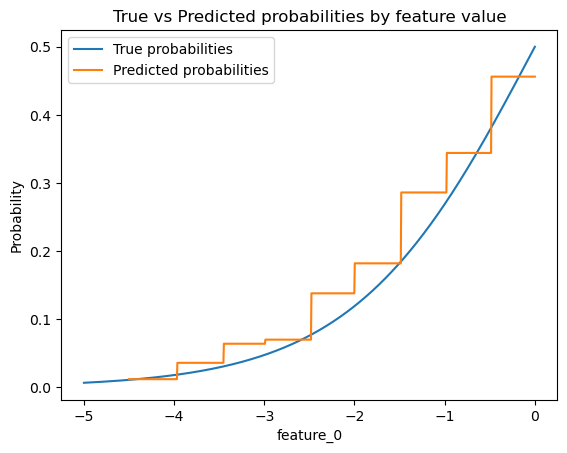

In [ ]:
df_preds = pd.DataFrame({"X": np.linspace(df[feature].min(), df[feature].max(), 1_000)})
df_preds["probs"] = 1 / (1 + np.exp(-df_preds["X"]))

df_preds["X_binned"] = pd.cut(df_preds["X"], bins=bin_edges)
df_preds = df_preds.merge(summary[["feature_0_10b", "woe"]], left_on="X_binned", right_on="feature_0_10b", how="left")

df_preds["preds"] = model.predict(sm.add_constant(df_preds["woe"]))

fig, ax = plt.subplots()
ax.plot(df_preds["X"], df_preds["probs"], label="True probabilities")
ax.plot(df_preds["X"], df_preds["preds"], label="Predicted probabilities")

ax.set_xlabel(feature)
ax.set_ylabel("Probability")
ax.set_title("True vs Predicted probabilities by feature value")
ax.legend();

---------

## Conclusions

The WoE transformation is a very simple and effective way to transform variables for logistic regression modelling. Its advantages include:
- Speed and ease of transformation
- Explainability
- Regularisation via binning

However, it does have some disadvantages:
- By binning we may be losing out on useful information (for this reason the actual binning process itself should be quite involved; it is important to select the bin edges carefully rather than just binning into equally sized groups)
- Binning results in step changes in predictions which may not be good for the chosen use case